### Importation des bibliothèques

Les bibliothèques nécessaires sont importées afin de manipuler les données et réaliser les visualisations ou graphiques.

In [71]:
%pip install seaborn matplotlib pandas numpy

Note: you may need to restart the kernel to use updated packages.


In [72]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [73]:
sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.figsize"] = (8, 5)

### Chargement des données

Le fichier `mesures_capteurs.csv` est importé dans un DataFrame nommé `df`. Ce DataFrame sera utilisé tout au long de l'atelier.

In [74]:
df = pd.read_csv("../data/mesures_capteurs.csv")

df

,id_mesure,date_heure,id_capteur,batiment,temperature,humidite,pression,consommation,etat
0,M0413,2026-01-22 04:00:00,C005,B002,25.46,58.06,1008.95,287.28,OK
1,M0290,2026-01-17 01:00:00,C002,B001,24.00,79.73,993.39,116.20,OK
2,M0077,2026-01-08 04:00:00,C005,B002,25.82,54.47,1010.32,288.50,OK
3,M0079,2026-01-08 06:00:00,C007,B003,28.23,69.39,1019.62,136.65,OK
4,M0183,2026-01-12 14:00:00,C003,B001,20.58,53.80,1016.58,182.62,OK
...,...,...,...,...,...,...,...,...,...
600,M0072,2026-01-07 23:00:00,C012,B004,23.67,60.28,1015.11,282.36,OK
601,M0107,2026-01-09 10:00:00,C011,B004,24.34,61.42,1019.43,357.43,OK
602,M0271,2026-01-16 06:00:00,C007,B003,23.73,63.49,1016.46,152.79,OK
603,M0436,2026-01-23 03:00:00,C004,B002,24.83,79.77,1017.05,170.97,OK


### Exploration des données

Une première inspection du DataFrame permet de vérifier que les données ont été correctement chargées et d'observer leur structure.

In [75]:
df.head()

df.info()

df.describe()

df.isnull().sum()

<class 'pandas.DataFrame'>
RangeIndex: 605 entries, 0 to 604
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id_mesure     605 non-null    str    
 1   date_heure    605 non-null    str    
 2   id_capteur    605 non-null    str    
 3   batiment      605 non-null    str    
 4   temperature   599 non-null    float64
 5   humidite      600 non-null    float64
 6   pression      600 non-null    float64
 7   consommation  600 non-null    float64
 8   etat          601 non-null    str    
dtypes: float64(4), str(5)
memory usage: 42.7 KB


id_mesure       0
date_heure      0
id_capteur      0
batiment        0
temperature     6
humidite        5
pression        5
consommation    5
etat            4
dtype: int64

### 1.1 Distribution des températures

Un histogramme est utilisé pour visualiser la répartition des températures mesurées par les capteurs. Une courbe de densité (KDE) est ajoutée afin de mieux observer la forme générale de la distribution.

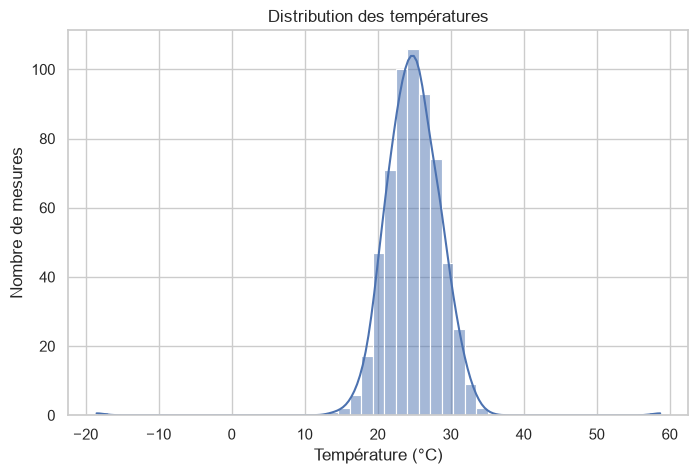

In [76]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="temperature",
    kde=True
)

plt.title("Distribution des températures")
plt.xlabel("Température (°C)")
plt.ylabel("Nombre de mesures")

plt.show()

### 1.2 Concentration des températures

L'histogramme montre que la majorité des températures est concentrée autour du pic principal de la distribution.

**Observation :**
- autour de 25 °C.

### 1.3 Symétrie de la distribution

La forme de l'histogramme permet d'évaluer si la distribution est symétrique.

**Observation :**
- Les deux côtés du pic sont similaires, la distribution est approximativement symétrique.
- Sinon, elle présente une asymétrie assez subtile et variable.

### 1.4 Valeurs extrêmes

Les valeurs très éloignées de la majorité des observations peuvent correspondre à des mesures atypiques.

**Observation :**
- On peut observer des valeurs extremes vers -20 ° et 60 °C.

### 1.5 Modification du nombre de classes

Le nombre de classes (bins) est augmenté afin d'obtenir une représentation plus détaillée de la distribution.

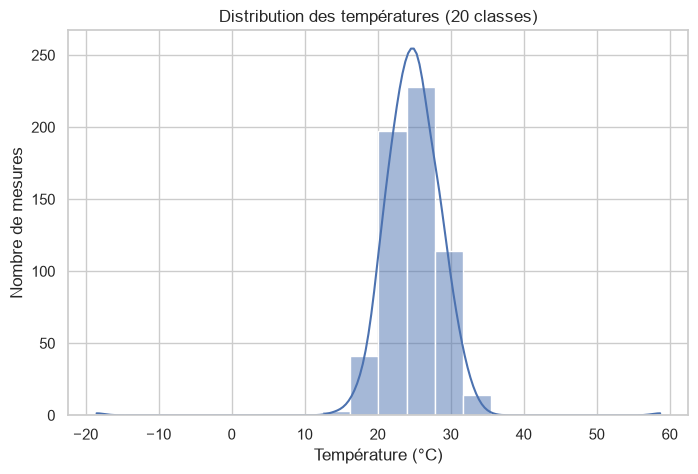

In [77]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="temperature",
    bins=20,
    kde=True
)

plt.title("Distribution des températures (20 classes)")
plt.xlabel("Température (°C)")
plt.ylabel("Nombre de mesures")

plt.show()

### 1.6 Distribution des températures par bâtiment

Les distributions sont comparées entre les bâtiments afin d'identifier d'éventuelles différences de comportement thermique.

<Figure size 1000x600 with 0 Axes>

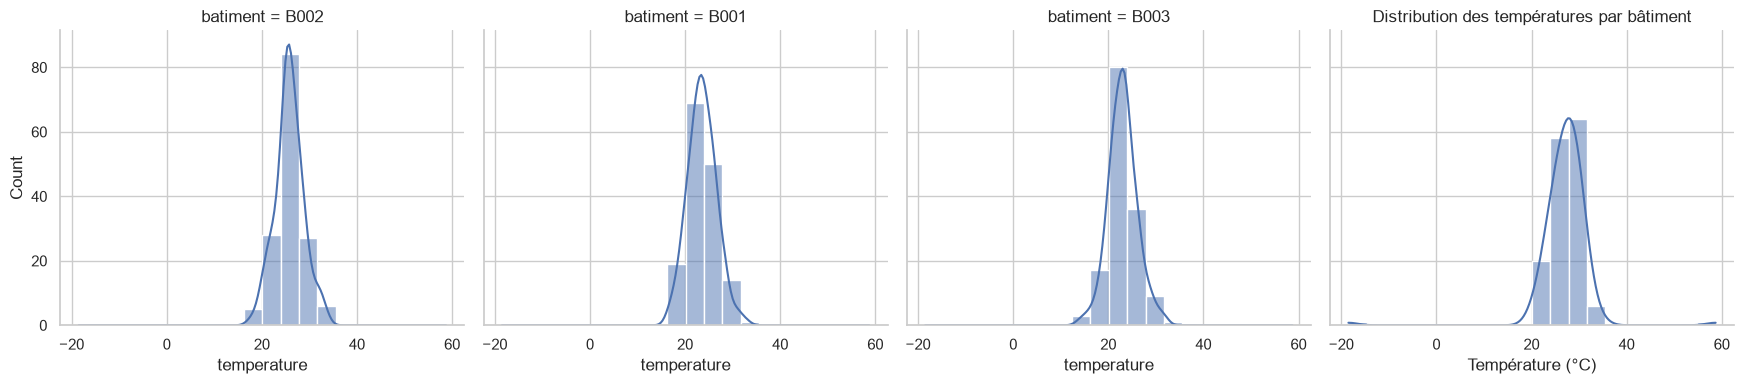

In [78]:
plt.figure(figsize=(10, 6))

sns.displot(
    data=df,
    x="temperature",
    col="batiment",
    bins=20,
    kde=True,
    height=4,
    aspect=1.1
)

plt.title("Distribution des températures par bâtiment")
plt.xlabel("Température (°C)")
plt.ylabel("Nombre de mesures")

plt.tight_layout()
plt.show()

### 2.1 Distribution des températures

La fonction `kdeplot()` permet d'estimer la densité de probabilité des températures. Contrairement à l'histogramme, elle fournit une courbe lissée qui met en évidence la forme générale de la distribution.

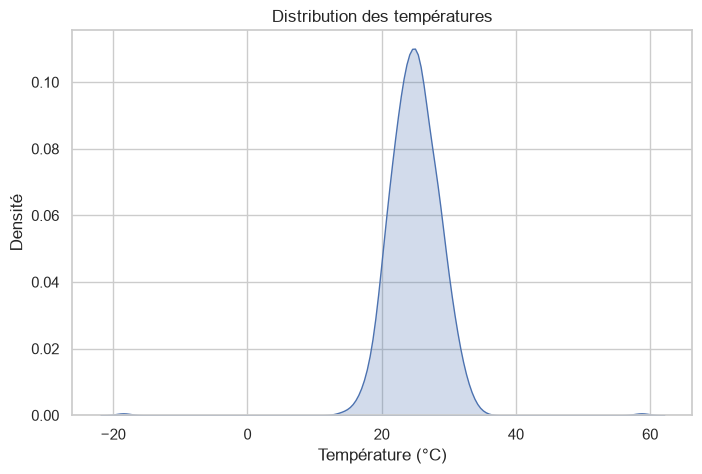

In [79]:
plt.figure(figsize=(8, 5))

sns.kdeplot(
    data=df,
    x="temperature",
    fill=True
)

plt.title("Distribution des températures")
plt.xlabel("Température (°C)")
plt.ylabel("Densité")

plt.show()

### 2.2 Distribution des températures par bâtiment

Les courbes de densité sont comparées entre les différents bâtiments afin d'observer les différences de répartition des températures et d'identifier les bâtiments présentant des comportements similaires ou distincts.

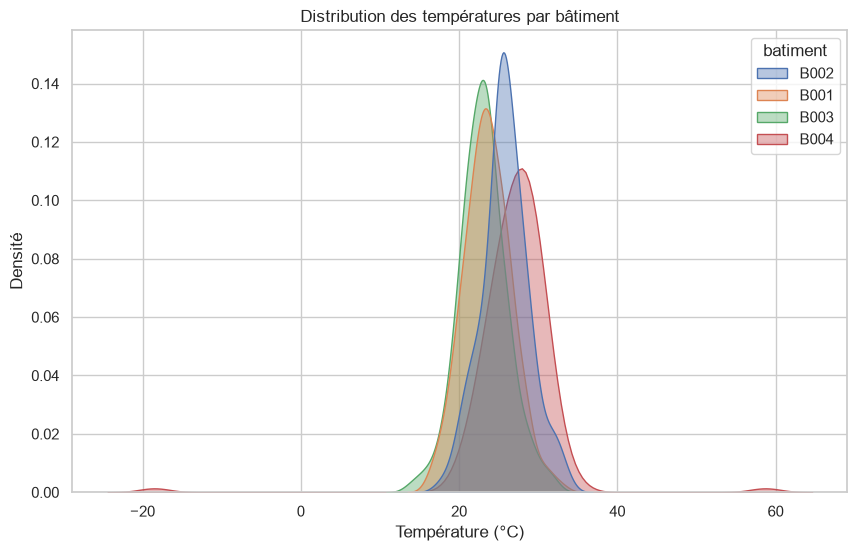

In [80]:
plt.figure(figsize=(10, 6))

sns.kdeplot(
    data=df,
    x="temperature",
    hue="batiment",
    fill=True,
    common_norm=False,
    alpha=0.4
)

plt.title("Distribution des températures par bâtiment")
plt.xlabel("Température (°C)")
plt.ylabel("Densité")

plt.show()

### 3.1 Distribution des températures

Le boxplot résume la distribution des températures à l'aide de cinq indicateurs : le minimum, le premier quartile (Q1), la médiane, le troisième quartile (Q3) et le maximum. Il permet également de mettre en évidence les valeurs extrêmes.

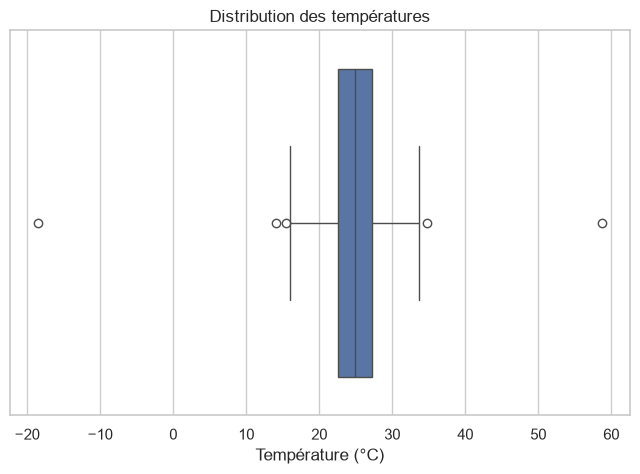

In [81]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="temperature"
)

plt.title("Distribution des températures")
plt.xlabel("Température (°C)")

plt.show()

### 3.2 Distribution des températures par bâtiment

Le boxplot est utilisé pour comparer la distribution des températures entre les différents bâtiments et mettre en évidence leurs différences.

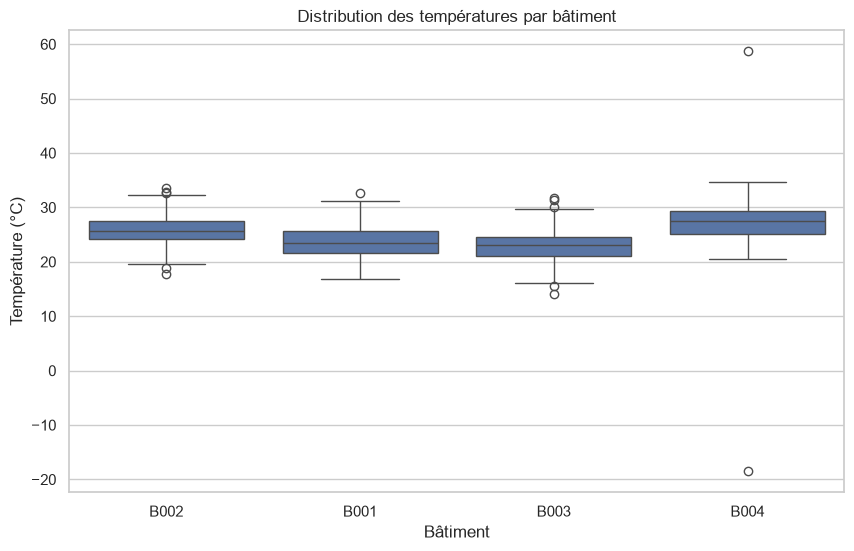

In [82]:
plt.figure(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="batiment",
    y="temperature"
)

plt.title("Distribution des températures par bâtiment")
plt.xlabel("Bâtiment")
plt.ylabel("Température (°C)")

plt.show()

### 3.3.a Médiane

La médiane correspond à la ligne située au centre de chaque boîte.

**Observation :**

- Le bâtiment **B004** possède la médiane la plus élevée.
- Les bâtiments **B001** et **B003** présentent des médianes légèrement plus faibles.
- Le bâtiment **B002** se situe entre les deux.

### 3.3.b Dispersion

La hauteur de la boîte représente la dispersion des températures.

**Observation :**

- Les bâtiments **B001**, **B002** et **B003** présentent une dispersion relativement similaire.
- Le bâtiment **B004** montre une dispersion légèrement plus importante, indiquant une variabilité plus élevée des températures.

### 3.3.c Valeurs extrêmes

Les points situés en dehors des moustaches correspondent aux valeurs extrêmes.

**Observation :**

- Les bâtiments **B001**, **B002** et **B003** possèdent quelques valeurs extrêmes proches de la distribution principale.
- Le bâtiment **B004** présente deux valeurs extrêmes très éloignées : une température très basse et une température très élevée.

### 3.4 Analyse des valeurs extrêmes

Le bâtiment **B004** possède les valeurs extrêmes les plus importantes du jeu de données.

Les autres bâtiments présentent également quelques valeurs atypiques, mais elles restent beaucoup plus proches de la distribution principale.

### 4.1 Distribution des températures

Le `violinplot()` combine les informations d'un boxplot avec une estimation de la densité des données. Il permet ainsi d'observer non seulement la médiane et la dispersion, mais aussi la forme de la distribution.

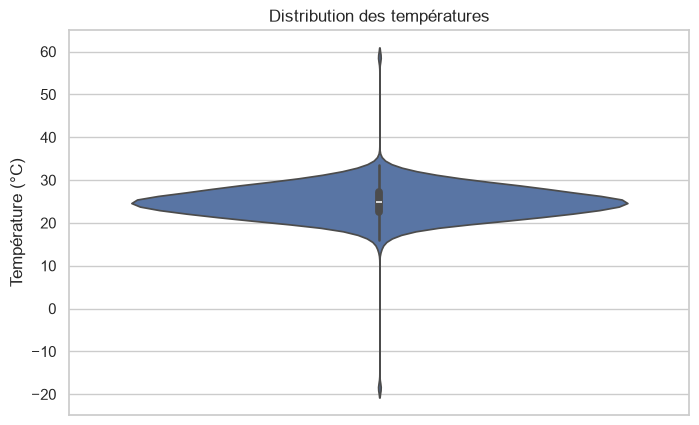

In [83]:
plt.figure(figsize=(8, 5))

sns.violinplot(
    data=df,
    y="temperature"
)

plt.title("Distribution des températures")
plt.ylabel("Température (°C)")

plt.show()

### 4.2 Distribution des températures par bâtiment

Le `violinplot()` est utilisé pour comparer la distribution des températures entre les différents bâtiments.

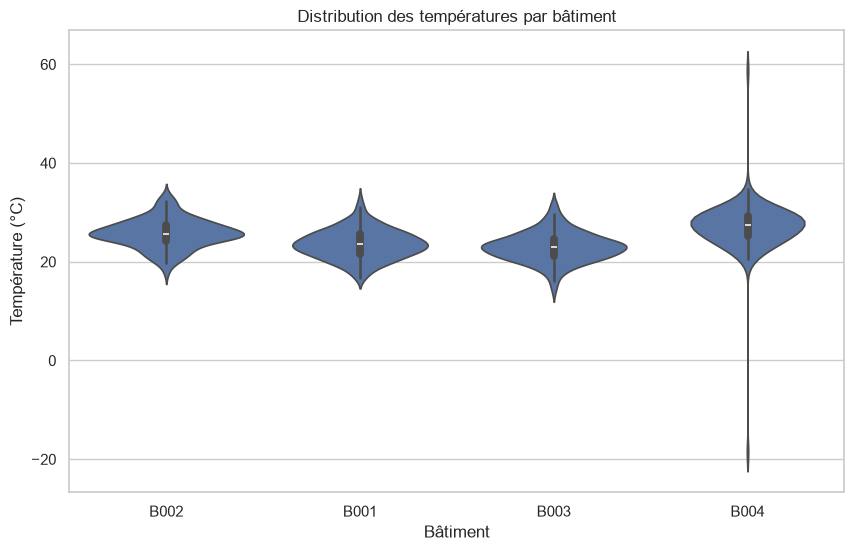

In [84]:
plt.figure(figsize=(10, 6))

sns.violinplot(
    data=df,
    x="batiment",
    y="temperature"
)

plt.title("Distribution des températures par bâtiment")
plt.xlabel("Bâtiment")
plt.ylabel("Température (°C)")

plt.show()

### 5.1 Nombre de mesures par état

Le graphique ci-dessous affiche le nombre de mesures enregistrées pour chaque état de fonctionnement des capteurs.

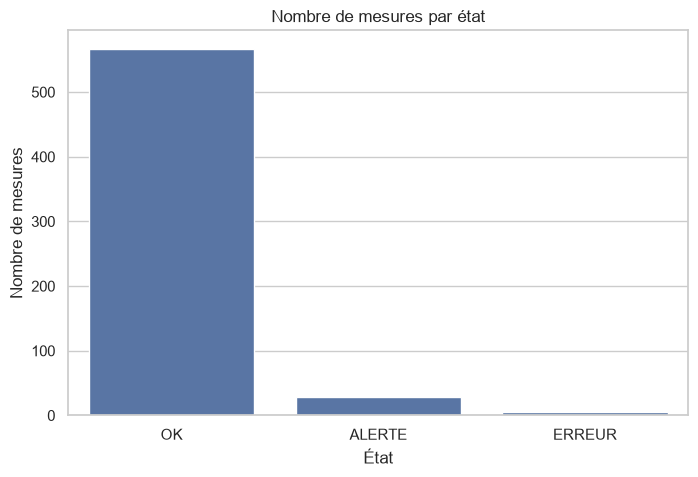

In [85]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="etat"
)

plt.title("Nombre de mesures par état")
plt.xlabel("État")
plt.ylabel("Nombre de mesures")

plt.show()

### 5.2 Nombre de mesures par bâtiment

Le graphique ci-dessous compare le nombre de mesures collectées dans chaque bâtiment.

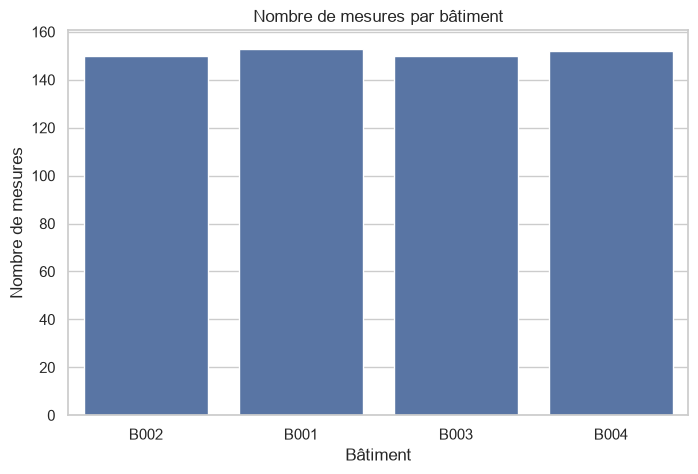

In [86]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="batiment"
)

plt.title("Nombre de mesures par bâtiment")
plt.xlabel("Bâtiment")
plt.ylabel("Nombre de mesures")

plt.show()

### 5.3 États des capteurs par bâtiment

Le graphique suivant compare les états des capteurs (OK, ALERTE et ERREUR) pour chaque bâtiment afin d'identifier leur répartition.

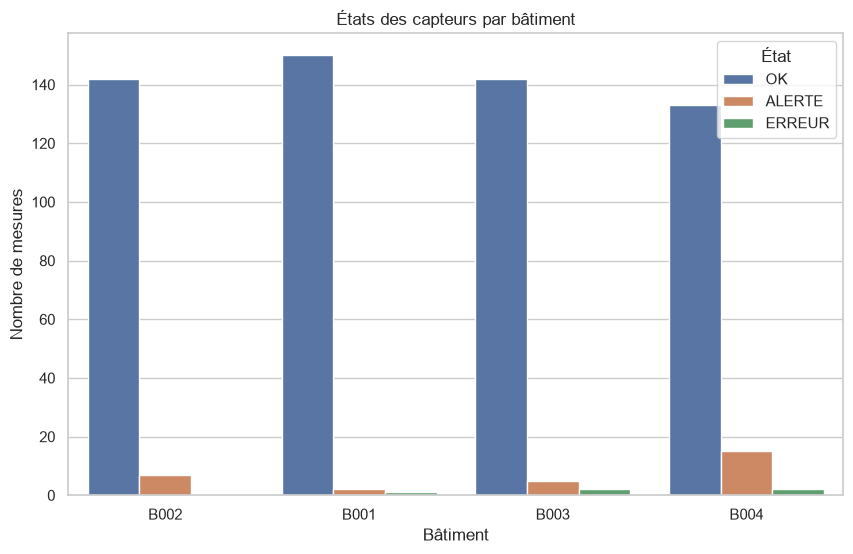

In [87]:
plt.figure(figsize=(10, 6))

sns.countplot(
    data=df,
    x="batiment",
    hue="etat"
)

plt.title("États des capteurs par bâtiment")
plt.xlabel("Bâtiment")
plt.ylabel("Nombre de mesures")

plt.legend(title="État")

plt.show()

### 5.3.a .b .c : États des capteurs par bâtiment

Ce graphique présente la répartition des mesures des capteurs selon leur état (**OK**, **ALERTE**, **ERREUR**) pour chaque bâtiment.

**Observation :**

- **a) Plus de mesures en état OK :** Le bâtiment **B001** possède le plus grand nombre de mesures en état OK (environ 150 mesures).
- **b) Plus de mesures en ALERTE :** Le bâtiment **B004** présente le plus de mesures en ALERTE (environ 15 mesures).
- **c) Plus de mesures en ERREUR :** Les bâtiments **B003** et **B004** affichent le plus de mesures en ERREUR, à égalité avec un volume très faible (environ 2 mesures chacun).

### 6.1 Relation entre température et consommation

Le graphique de dispersion (`scatterplot`) permet d'observer la relation entre la température et la consommation énergétique des capteurs.

Chaque point représente une mesure.

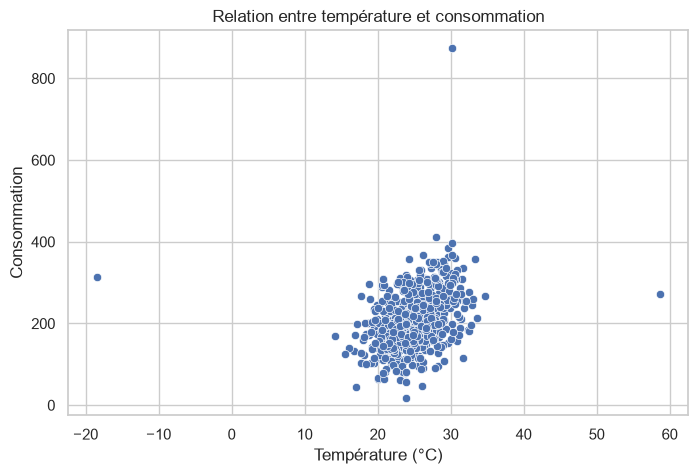

In [88]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="temperature",
    y="consommation"
)

plt.title("Relation entre température et consommation")
plt.xlabel("Température (°C)")
plt.ylabel("Consommation")

plt.show()

#### Relation entre température et consommation

Ce graphique en nuage de points étudie la corrélation entre la température (°C) et le niveau de consommation.

**Observation :**

- **Distribution principale :** La majorité des données est regroupée sous forme de nuage dense entre **15°C et 35°C** pour une consommation variant de **50 à 400**. Il n'y a pas de tendance linéaire fortement marquée, mais une légère tendance positive semble visible au cœur du nuage.
- **Valeurs extrêmes :** Quatre points aberrants s'écartent nettement du groupe principal :
  - Un pic de consommation extrême supérieur à **800** pour une température d'environ 30°C.
  - Deux températures anormales : une température très basse proche de **-20°C** et une température très élevée proche de **60°C** (avec des consommations standards d'environ 300).
  - Un point isolé à faible température (environ 14°C) et faible consommation.


### 6.2 Relation entre température et consommation par bâtiment

Les points sont colorés selon le bâtiment afin de comparer le comportement de chaque bâtiment.

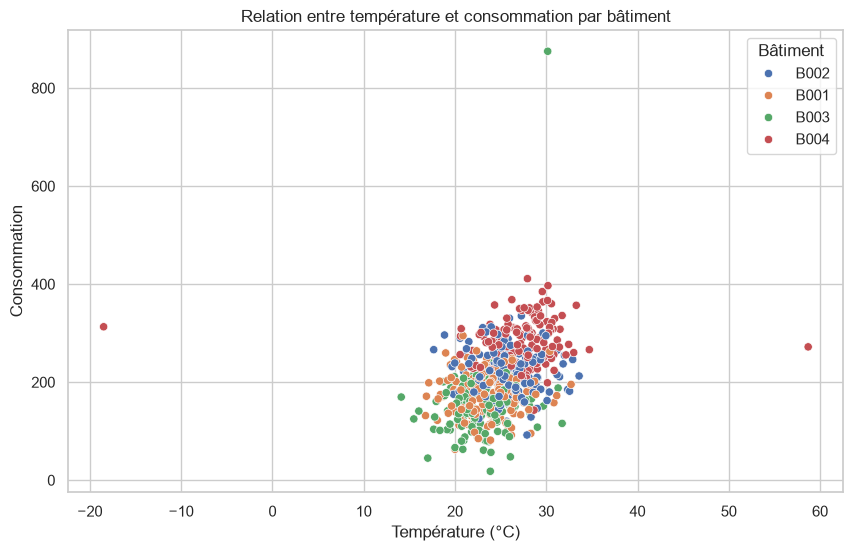

In [89]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="temperature",
    y="consommation",
    hue="batiment"
)

plt.title("Relation entre température et consommation par bâtiment")
plt.xlabel("Température (°C)")
plt.ylabel("Consommation")

plt.legend(title="Bâtiment")

plt.show()

#### Relation entre température et consommation par bâtiment

Ce graphique en nuage de points colore la relation précédente par bâtiment pour identifier le comportement de chacun.

**Observation :**

- **Distribution principale :** Le comportement global reste similaire entre les bâtiments, mais le bâtiment **B004** (rouge) tend à avoir les consommations les plus élevées du nuage, tandis que le bâtiment **B003** (vert) regroupe les consommations les plus basses.
- **Attribution des valeurs extrêmes :** 
  - Le pic de consommation extrême (>800) appartient exclusivement au bâtiment **B003**.
  - Les deux anomalies de températures extrêmes (-18°C et 59°C) proviennent uniquement du bâtiment **B004**.


### 6.3 Modification de la taille des points

La taille des points est augmentée afin d'améliorer la lisibilité du graphique.

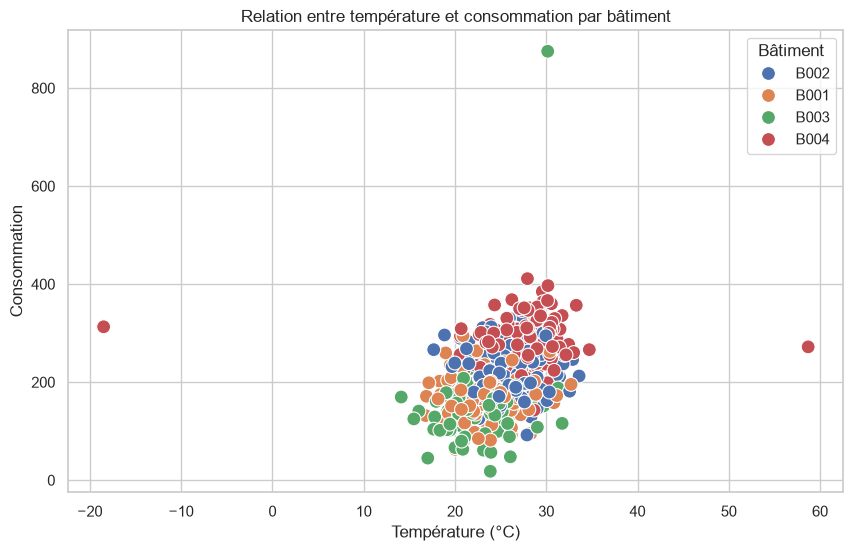

In [90]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="temperature",
    y="consommation",
    hue="batiment",
    s=100
)

plt.title("Relation entre température et consommation par bâtiment")
plt.xlabel("Température (°C)")
plt.ylabel("Consommation")

plt.legend(title="Bâtiment")

plt.show()

### 7.1 Relation entre température et consommation

Le `regplot()` ajoute une droite de régression au nuage de points. Il permet de visualiser la tendance générale entre la température et la consommation énergétique.

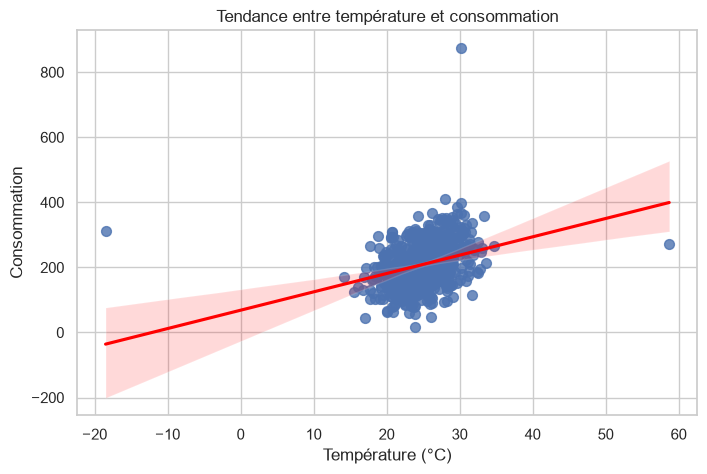

In [91]:
plt.figure(figsize=(8, 5))

sns.regplot(
    data=df,
    x="temperature",
    y="consommation",
    scatter_kws={"s": 50},
    line_kws={"color": "red"}
)

plt.title("Tendance entre température et consommation")
plt.xlabel("Température (°C)")
plt.ylabel("Consommation")

plt.show()

#### Tendance entre température et consommation

Ce graphique superpose une droite de régression linéaire et son intervalle de confiance sur le nuage de points pour modéliser la tendance globale.

**Observation :**

- **Tendance générale :** La droite rouge montre une corrélation linéaire positive. La consommation globale augmente proportionnellement lorsque la température augmente.
- **Fiabilité du modèle :** L'intervalle de confiance (zone rose) est très resserré au niveau du nuage de points principal (15°C à 35°C), indiquant une bonne fiabilité locale. En revanche, il s'élargit fortement vers les températures extrêmes en raison du manque de données et du poids des valeurs aberrantes (-18°C et 59°C) sur la pente.


### 8.1 Relation entre température et consommation par bâtiment

Le `lmplot()` permet d'afficher une droite de régression pour chaque bâtiment afin de comparer leurs tendances respectives.

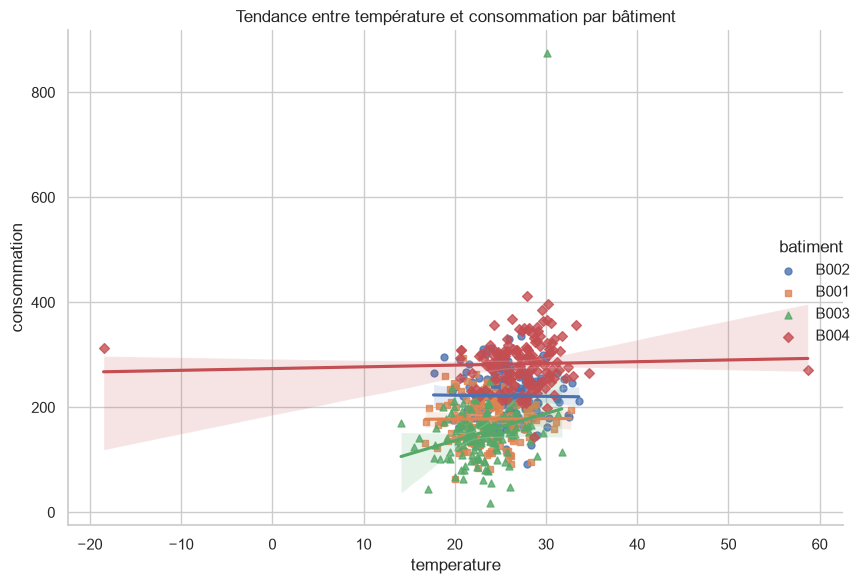

In [92]:
sns.lmplot(
    data=df,
    x="temperature",
    y="consommation",
    hue="batiment",
    height=6,
    aspect=1.3,
    scatter_kws={"s": 25},
    markers=["o", "s", "^", "D"]
)

plt.title("Tendance entre température et consommation par bâtiment")

plt.tight_layout()
plt.show()

#### Tendance entre température et consommation par bâtiment

Ce graphique `lmplot()` décline les droites de régression linéaire et leurs intervalles de confiance pour chaque bâtiment individuellement.

**Observation :**

- **Bâtiment B003 (vert) :** Il présente la pente positive la plus inclinée et marquée. Sa consommation augmente de manière significative et claire avec la hausse de la température.
- **Bâtiment B001 (orange) :** Il affiche une pente positive plus légère, indiquant une augmentation modérée de la consommation avec la température.
- **Bâtiment B002 (bleu) :** Sa droite est presque plate (légèrement négative), traduisant une consommation stable qui ne dépend pas de la température constatée.
- **Bâtiment B004 (rouge) :** La droite est quasiment horizontale avec un intervalle de confiance (zone rose) très large aux extrémités. La tendance y est plate, fortement influencée et biaisée par les deux valeurs de température aberrantes (-18°C et 59°C).


### 9.1 Calcul des corrélations

Les corrélations entre la température, l'humidité, la pression et la consommation sont calculées à l'aide de Pandas afin de mesurer la force et le sens de la relation entre ces variables.

In [93]:
correlation = df[
    ["temperature", "humidite", "pression", "consommation"]
].corr()

### 9.2 Matrice de corrélation

La matrice de corrélation présente les coefficients de corrélation entre chaque paire de variables.

In [94]:
correlation

,temperature,humidite,pression,consommation
temperature,1.000000,-0.006126,0.061283,0.317048
humidite,-0.006126,1.000000,0.045242,-0.046061
pression,0.061283,0.045242,1.000000,0.056051
consommation,0.317048,-0.046061,0.056051,1.000000


### 9.3 Heatmap des corrélations

Une carte thermique facilite la lecture de la matrice de corrélation grâce à un code couleur.

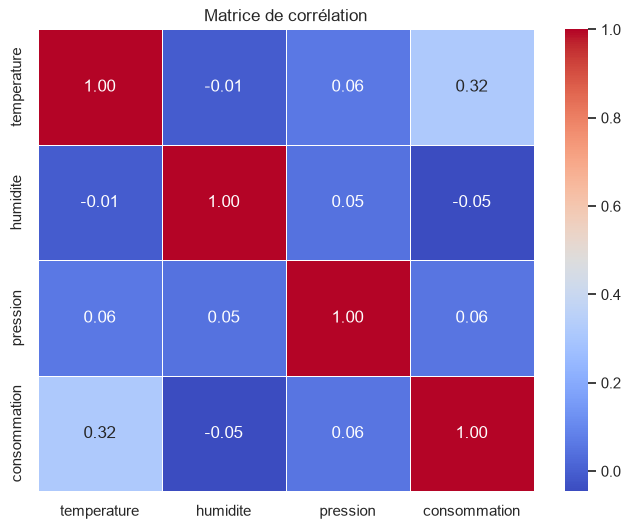

In [95]:
plt.figure(figsize=(8, 6))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Matrice de corrélation")

plt.show()

#### Observations sur la Heatmap

Cette carte thermique (*heatmap*) affiche les coefficients de corrélation de Pearson entre les différentes variables météo et de consommation.

**Observation :**

- **a) Corrélations positives :** La seule relation positive notable lie la **température** et la **consommation** avec un coefficient de **0,32**. La relation entre la pression et la consommation est également positive mais négligeable (**0,06**), tout comme celle entre pression et température (**0,06**).
- **b) Corrélations négatives :** Les seules corrélations négatives, bien que très faibles, concernent l'**humidité** par rapport à la **consommation** (**-0,05**) et à la **température** (**-0,01**).
- **c) Corrélations proches de zéro :** La quasi-totalité des variables hors diagonale ont des coefficients proches de zéro (**-0,01**, **0,05**, **0,06**, **-0,05**), ce qui indique une absence de relation linéaire entre elles (par exemple entre l'humidité et la pression).
- **d) Variables fortement liées :** Aucune variable ne présente de corrélation linéaire forte (coefficients proches de 1 ou -1) en dehors de la diagonale parfaite de l'auto-corrélation (1,00). Le couple **température et consommation** (**0,32**) constitue la seule liaison statistique digne d'intérêt, bien qu'elle reste d'intensité modérée.


### 10.1 Analyse multivariée

Le `pairplot()` affiche simultanément les distributions individuelles des variables numériques et les graphiques de dispersion entre chaque paire de variables.

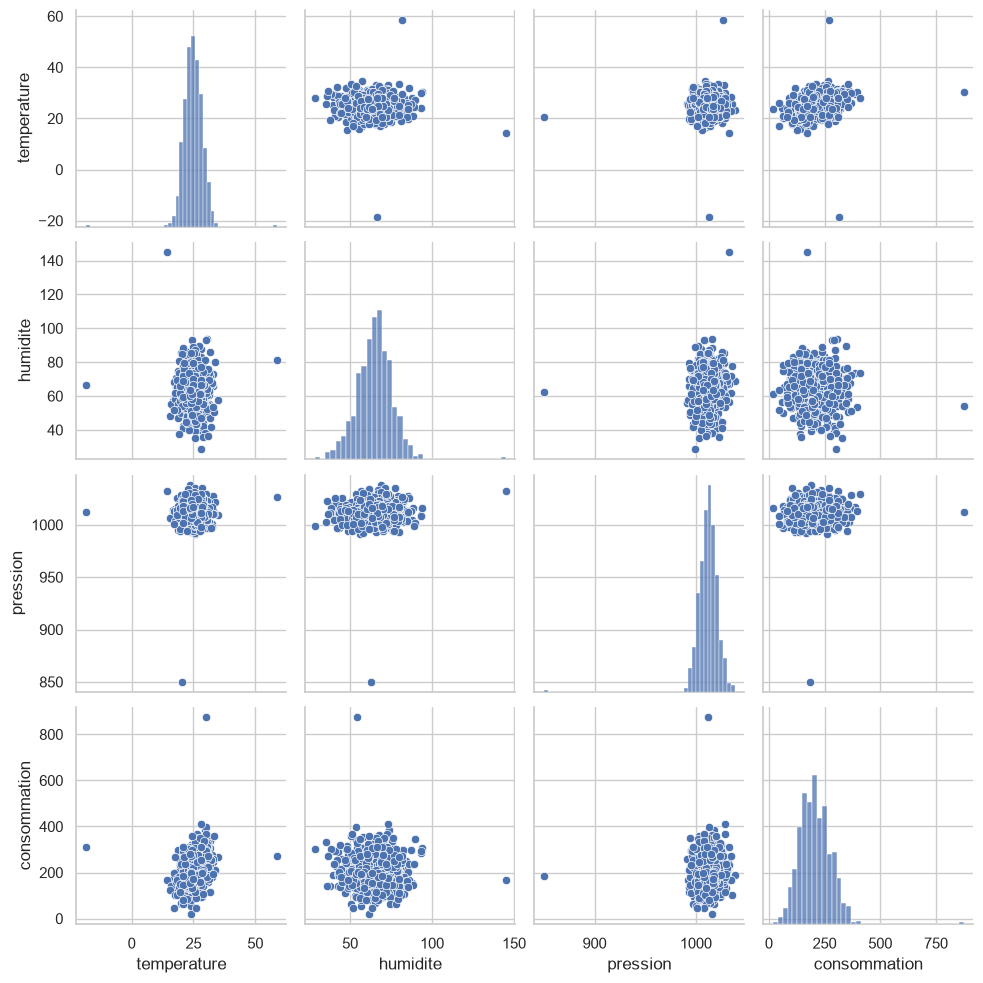

In [96]:
sns.pairplot(
    df[
        ["temperature", "humidite", "pression", "consommation"]
    ]
)

plt.show()

#### Analyse multivariée (Pairplot)

Ce graphique en matrice de diagrammes (`pairplot`) croise simultanément les distributions individuelles (en diagonale) et les relations bidimensionnelles (hors diagonale) des variables météo et de consommation.

**Observation :**

- **Distributions individuelles (diagonale) :** Les quatre variables (**température**, **humidité**, **pression** et **consommation**) suivent des distributions de type gaussien (courbes en cloche), centrées sur leurs moyennes respectives.
- **Relations bidimensionnelles (nuages de points) :** La majorité des croisements se présentent sous forme de nuages circulaires ou compacts, confirmant l'absence de fortes corrélations linéaires à l'exception du couple **température / consommation** qui montre un étalement légèrement plus étiré.
- **Mise en évidence des anomalies :** Le graphique isole visuellement de manière très nette les points aberrants déjà identifiés (comme la consommation supérieure à 800, la température proche de -20°C ou de 60°C, et une valeur d'humidité extrême supérieure à 140).


### 11.1 Sauvegarde au format PNG

Les graphiques sont enregistrés dans le dossier `exports` au format PNG.

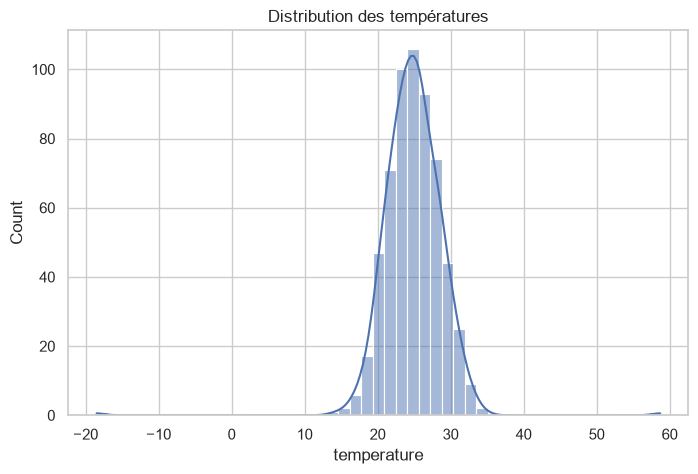

In [97]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="temperature",
    kde=True
)

plt.title("Distribution des températures")

plt.savefig("../exports/temperature.png", dpi=300)

plt.show()

### 11.2 Sauvegarde au format PDF

Le même graphique est également enregistré au format PDF.

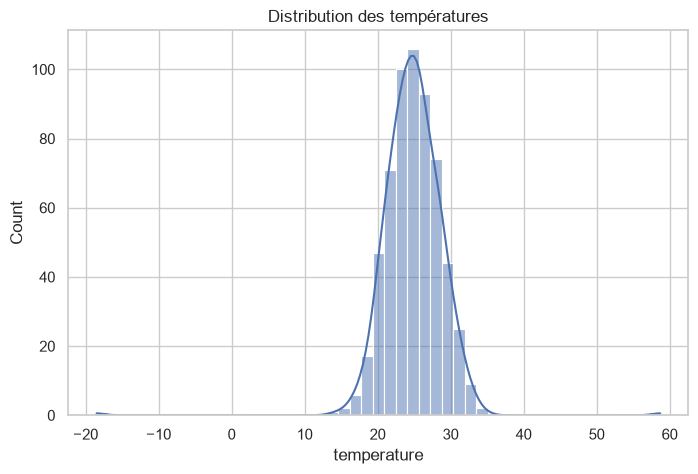

In [98]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df,
    x="temperature",
    kde=True
)

plt.title("Distribution des températures")

plt.savefig("../exports/temperature.pdf")

plt.show()